# Project Title : Car Market Insights - What Makes a Used Car Worth More?


1. Project Description : 
- This project analyzes used car market data to understand how factors like age, mileage, fuel type and transmission affect vehicle resale values. By identifying these pricing patterns, the project provides clear insights to help buyers, sellers and dealers make smarter pricing decisions.


2. Problem Statement : 
- Pricing used cars accurately is difficult because a vehicle's value drops unpredictably over time. Without clear market data, buyers risk overpaying and sellers or dealers risk losing money by mispricing their inventory.


3. About Dataset :
The dataset contains key details about various used cars, including:

- Vehicle Age & Mileage: How old the car is and how many kilometers it has been driven.

- Engine & Transmission: Fuel type (Petrol, Diesel, CNG) and gearbox type (Manual or Automatic).

- Price Information: Original new price, actual used selling price and previous owner count.


4. Objective :
- Identify key factors that cause a car's price to drop over time.

- Compare how automatic and manual vehicles hold their value as they age.

- Provide easy-to-understand recommendations for pricing and stocking used cars.


In [1]:
# Import Library 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import date 

## Data Load and Exploration 

In [2]:
# Data Load
df = pd.read_csv(r'C:\VOIS Internship\Car Market Trend\data\Car_Market_Trends_Analysis_with_Car_Dekho_Data.csv')
print(f"""Dataset Column and records count : 
        {df.count()}""")

Dataset Column and records count : 
        Car_Name         301
Year             301
Selling_Price    301
Present_Price    301
Kms_Driven       301
Fuel_Type        301
Seller_Type      301
Transmission     301
Owner            301
dtype: int64


In [3]:
# Dataset Structure
print(f"""Dataset Structure : {df.shape}""")

Dataset Structure : (301, 9)


In [4]:
#df.head() # top 5 rows
df.tail(10) # bottom 5 rows

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
291,brio,2015,5.40,6.10,31427,Petrol,Dealer,Manual,0
292,jazz,2016,6.40,8.40,12000,Petrol,Dealer,Manual,0
293,city,2010,3.25,9.90,38000,Petrol,Dealer,Manual,0
294,amaze,2014,3.75,6.80,33019,Petrol,Dealer,Manual,0
295,city,2015,8.55,13.09,60076,Diesel,Dealer,Manual,0
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.90,5464,Petrol,Dealer,Manual,0


In [5]:
# Check datatype and Null value count
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [6]:
# Descriptive Summary 
df.describe()




,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [7]:
# Data Quality Check 

#1. Duplicate Value -  2 duplicate values found 
duplicate_count = df.duplicated().sum() #
print(f'Duplicate count : {duplicate_count}')
df.drop_duplicates(inplace=True)

Duplicate count : 2


In [8]:
#2. Null Value - No null value found

missing_value = pd.DataFrame({
    'Missing Count' : df.isna().sum(),
    'Missing Pct' : (df.isna().mean()*100).round(2)
})
print(missing_value)

               Missing Count  Missing Pct
Car_Name                   0          0.0
Year                       0          0.0
Selling_Price              0          0.0
Present_Price              0          0.0
Kms_Driven                 0          0.0
Fuel_Type                  0          0.0
Seller_Type                0          0.0
Transmission               0          0.0
Owner                      0          0.0


## Data Analysis  

In [9]:
# Before Performing analysis we are making copy of orignal data ,so during  analysis it  doesn't affect original data
df_copy = df.copy()

df_copy




,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [10]:
# Feature Engineering 

# 1. Car Age
current_year = date.today().year
df_copy["Car_Age"] = current_year - df_copy["Year"] 

# 2. Car Value Depreciation 
df_copy['Depreciation_Amount'] = df_copy['Present_Price'] - df_copy['Selling_Price']
df_copy['Depreciation_Pct'] = (df_copy['Depreciation_Amount'] / df_copy['Selling_Price'] * 100).round(2)
df_copy

# 3. Mileage Bucket 
mileage_labels = ['0-25k', '25k-50k', '50k-75k', '75k-100k', '100k+']
mileage_bins = [0, 25000, 50000, 75000, 100000, np.inf]
df_copy['Mileage_Bucket'] = pd.cut(df_copy['Kms_Driven'], bins=mileage_bins, labels=mileage_labels)

In [11]:
# # Outliers Detection  : 
# Q1 = df_copy['Selling_Price'].quantile(0.25)
# Q3 = df_copy['Selling_Price'].quantile(0.75)

# IQR = Q3 - Q1

# lower = Q1 - 1.5 * IQR
# upper = Q3 + 1.5 * IQR

# df_copy.loc[
#     (df_copy['Selling_Price'] < lower) | (df_copy['Selling_Price'] > upper),
#     'Selling_Price'
# ] = np.nan

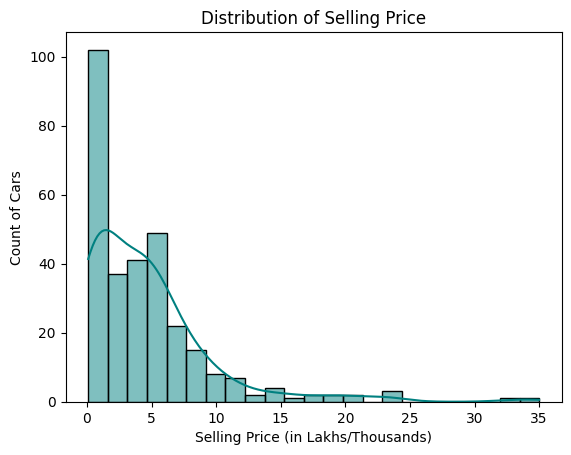

In [12]:
# 1. Selling Price Distribution 
sns.histplot(df_copy["Selling_Price"], kde=True, color="teal")
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price (in Lakhs/Thousands)")
plt.ylabel("Count of Cars")
plt.savefig("price_distribution.jpg")
plt.show()


1. Distribution of Selling Price

- Explanation: Most used cars sell at lower prices (0 to 5 Lakhs), with very few high-value luxury cars listed above 15 Lakhs.

- Recommendations:

  - Focus marketing and inventory on budget-friendly cars under 5 Lakhs, as demand is highest here.

  - Stock premium cars sparingly since they sell in far lower volumes.

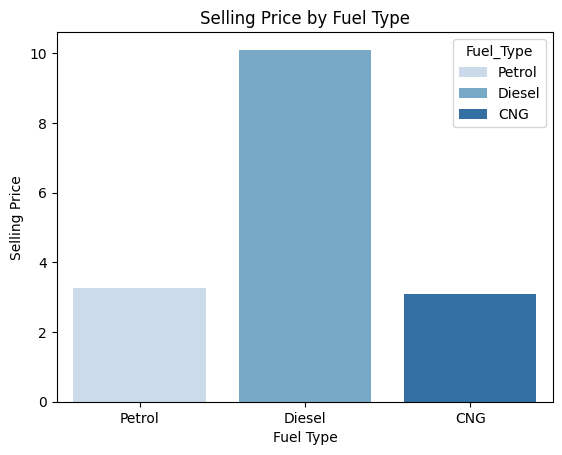

In [13]:
# Fuel Type vs Selling Price
sns.barplot(x="Fuel_Type", y="Selling_Price", data=df_copy,hue='Fuel_Type', errorbar=None, palette="Blues",legend=True)
plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")
plt.savefig("price_fueltype.jpg")
plt.show()


# Selling Price by Fuel Type

- Explanation: Diesel cars command significantly higher selling prices compared to Petrol and CNG vehicles.

- Recommendations:

    - Acquire and feature diesel vehicles to drive higher revenue per sale.

    - Market Petrol and CNG vehicles as affordable alternatives for daily urban commutes.

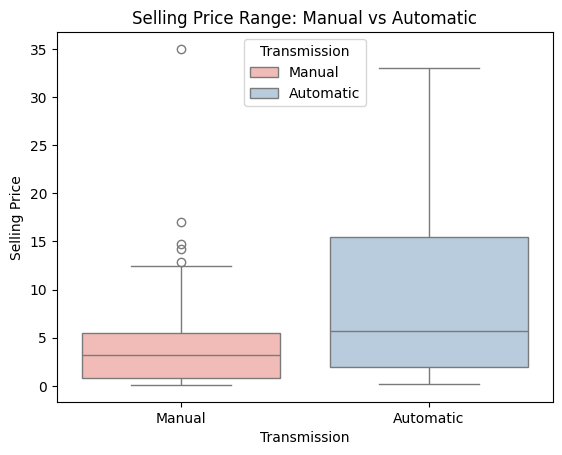

In [14]:
# Transmission vs Selling Price
sns.boxplot(x="Transmission", y="Selling_Price", data=df_copy,hue='Transmission', palette="Pastel1", legend=True)
plt.title("Selling Price Range: Manual vs Automatic")
plt.xlabel("Transmission")
plt.ylabel("Selling Price")
plt.savefig("price_transmission.jpg")
plt.show()


# Selling Price Range: Manual vs Automatic

- Explanation: Automatic cars generally sell for slightly higher average prices than manual cars, though manual cars have a wider overall price spread.

- Recommendations:

    - Highlight automatic cars for customers looking for higher resale value or premium options.

    - Offer manual cars to price-conscious buyers seeking reliable, lower-cost entry options.

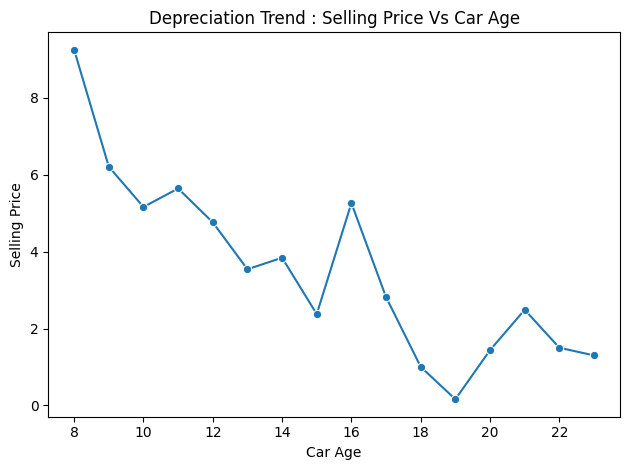

In [15]:
# Depreciation Trend : Selling Price Vs Car Age
sns.lineplot(data=df_copy, x="Car_Age", y="Selling_Price", marker="o", errorbar=None)
plt.title("Depreciation Trend : Selling Price Vs Car Age")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")
plt.tight_layout()
plt.savefig("price_depreicaitontrend.jpg")
plt.show()

# Depreciation Trend: Selling Price Vs Car Age

- Explanation: A car's selling price drops dramatically in its first few years (ages 8 to 10) and continues to decline gradually as it gets older.

- Recommendations:

    - Buy newer used cars (under 10 years old) for higher resale margins.

    - Price older cars competitively to prevent them from sitting in inventory too long.

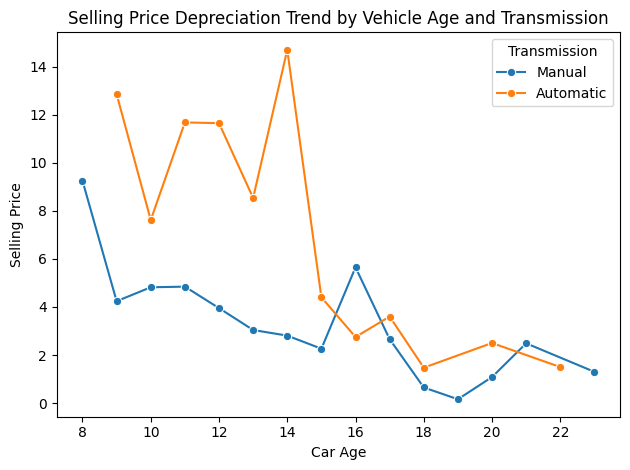

In [ ]:
# Depreciation Trend: Sellin Price Vs Vehicle Age and Transmission
sns.lineplot(data=df_copy, x="Car_Age", y="Selling_Price", hue="Transmission", marker="o", errorbar=None)
plt.title("Selling Price Depreciation Trend by Vehicle Age and Transmission")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")
plt.tight_layout()
plt.savefig('deprecationbytransmission.jpg')
plt.show()





# Depreciation Trend by Vehicle Age and Transmission

- Explanation

    - Automatic cars hold significantly higher resale value than manual cars up to age 14, after which both transmission types experience a sharp decline and converge at low prices past 15 years.

- Recommendations

    - Focus on younger automatic cars (under 14 years): Stock up on automatic vehicles in the 8–14 year range, as they yield much higher resale margins than manuals.

    - Liquidate automatic inventory before year 15: Sell off automatic cars before they reach 15 years of age to avoid the massive drop in value.

    - Keep aging manual prices low and steady: Position older manual cars (ages 8+) as budget-friendly entry options since their prices decline gradually without major shocks.

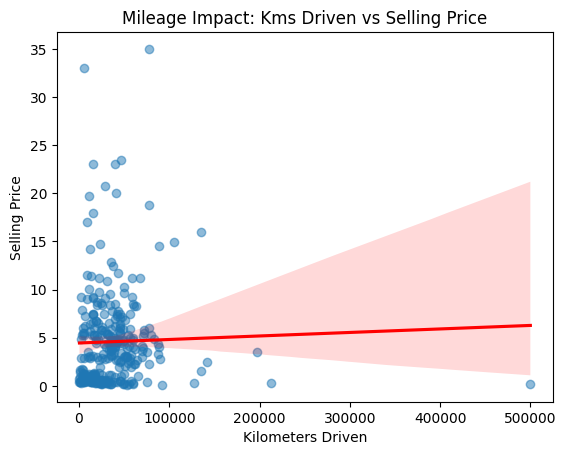

In [ ]:
# Mileage Impact: Kms Driven vs Selling Price
sns.regplot(data=df_copy, x="Kms_Driven", y="Selling_Price", # robust=True,  # Ignores the outlier's leverage when drawing the line
    #ci=None,  # Speed up calculation by turning off confidence interval
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title("Mileage Impact: Kms Driven vs Selling Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")
#plt.xlim(-5000, 150000)
plt.savefig("price_mileageimpact.jpg")
plt.show()

# Mileage Impact: Kms Driven vs Selling Price

- Explanation: The majority of cars listed have under 100,000 kilometers on the odometer and higher mileage tends to push selling prices down.

- Recommendations:

    - Prioritize acquiring cars with low overall mileage to maintain strong profit margins.

    - Discount high-mileage cars early to ensure faster inventory turnover.

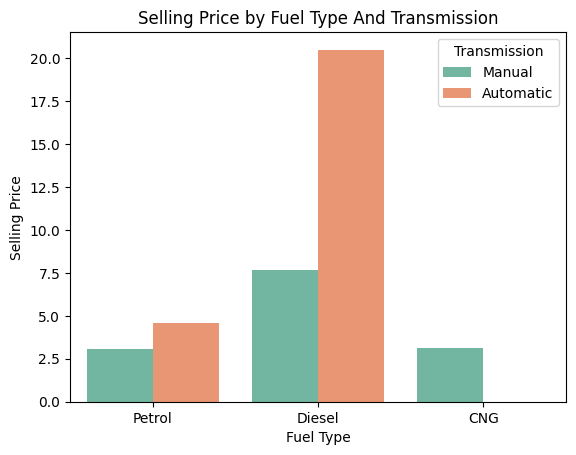

In [18]:
# Fuel & Transmission Preference Shifts
sns.barplot(data=df_copy,x='Fuel_Type',y="Selling_Price",hue="Transmission",errorbar=None, palette="Set2")
plt.title("Selling Price by Fuel Type And Transmission")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")
plt.show()

# Fuel & Transmission Preference Shifts
- Explanation: Automatic Diesel vehicles command a significantly higher resale price (~₹20.5L) compared to all other combinations, while Petrol and CNG models consistently sell at lower price points (₹3L to ₹4.5L).

- Recommendation: Prioritize sourcing Diesel Automatic vehicles for higher profit margins and keep CNG/Petrol Manuals for fast-moving, budget-conscious inventory.

Owner
0    288
1     10
3      1
Name: count, dtype: int64
Owner
0    96.321070
1     3.344482
3     0.334448
Name: proportion, dtype: float64


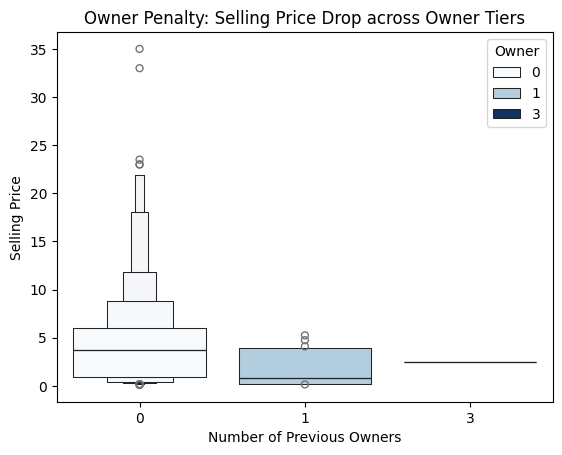

In [19]:
# Owner Penalty 
# Check how many cars are in each owner category
print(df_copy["Owner"].value_counts())
print(df_copy["Owner"].value_counts(normalize=True)*100)
sns.boxenplot(data=df_copy,x="Owner",y="Selling_Price",hue = "Owner", palette="Blues")
plt.title("Owner Penalty: Selling Price Drop across Owner Tiers")
plt.xlabel("Number of Previous Owners")
plt.ylabel("Selling Price")
plt.savefig("price_ownerpenalty.jpg")
plt.show()


# Owner Penalty: Selling Price Drop across Owner Tiers

- Explanation: Cars with 0 previous transfer records sell for much higher prices than cars with 1 or more previous owners.

- Recommendations:

    - Heavily promote single-owner / first-hand used vehicles as premium listings.

    - Offer price adjustments or warranty incentives to attract buyers for multi-owner cars

Mileage_Bucket
0-25k       128
25k-50k     105
50k-75k      46
75k-100k     12
100k+         8
Name: count, dtype: int64


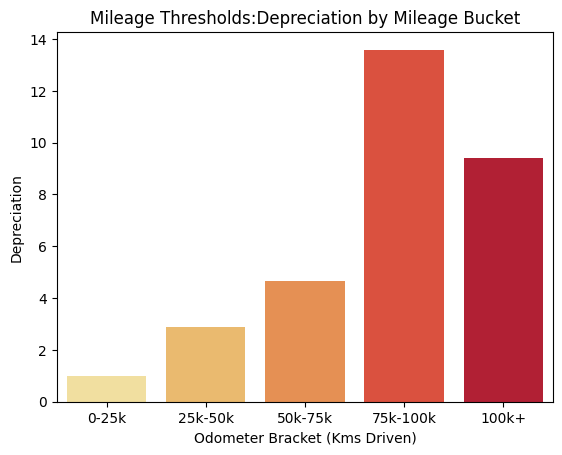

In [26]:
# Odometer Milestones 
a = df_copy['Mileage_Bucket'].value_counts()
print(a)
sns.barplot(data=df_copy, x="Mileage_Bucket", y="Depreciation_Amount", hue="Mileage_Bucket", errorbar=None, palette="YlOrRd")
plt.title("Mileage Thresholds:Depreciation by Mileage Bucket")
plt.xlabel("Odometer Bracket (Kms Driven)")
plt.ylabel("Depreciation")
plt.savefig("price_mileagebucket.jpg")
plt.show()



5. Mileage Thresholds: Depreciation by Mileage Bucket

- Explanation: Value loss accelerates sharply once a car crosses 75,000 to 100,000 kilometers.

- Recommendations:

    - Sell cars before they hit the 75,000 km mark to avoid severe price drops.

    - Set aggressive discount pricing for any inventory reaching 75k+ kilometers.

              min  median   max  count
Seller_Type                           
Dealer       1.05   5.250  35.0    193
Individual   0.10   0.515  16.0    106


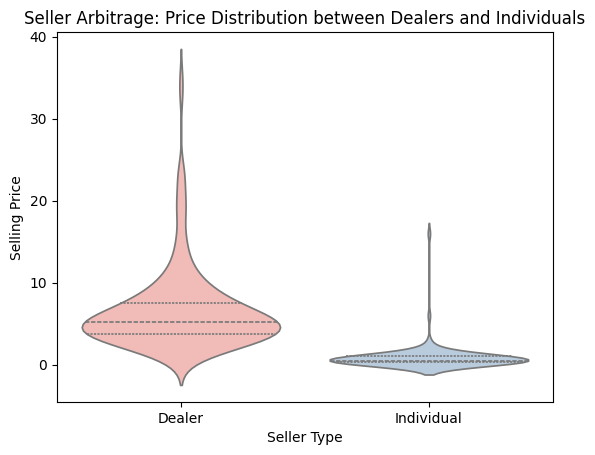

In [ ]:
# Seller Arbitrage: Price Distribution between Dealers and Individuals


# Calculate key price statistics for each Seller Type
seller_stats = df_copy.groupby("Seller_Type")["Selling_Price"].agg(
    ["min", "median", "max", "count"]
)
print(seller_stats)

sns.violinplot(data=df_copy, x="Seller_Type", y="Selling_Price", hue="Seller_Type", palette="Pastel1", inner="quartile")
plt.title("Seller Arbitrage: Price Distribution between Dealers and Individuals")
plt.xlabel("Seller Type")
plt.ylabel("Selling Price")
plt.savefig("price_seller.jpg")
plt.show()


# Seller Arbitrage: Price Distribution between Dealers and Individuals

- Explanation: Dealers list and sell cars at much higher price points than individual private sellers.

- Recommendations:

    - Source inventory directly from individual sellers at lower prices to maximize profit.

    - Emphasize dealer benefits—like inspections, refurbishment and warranties—to justify higher showroom prices to buyers.

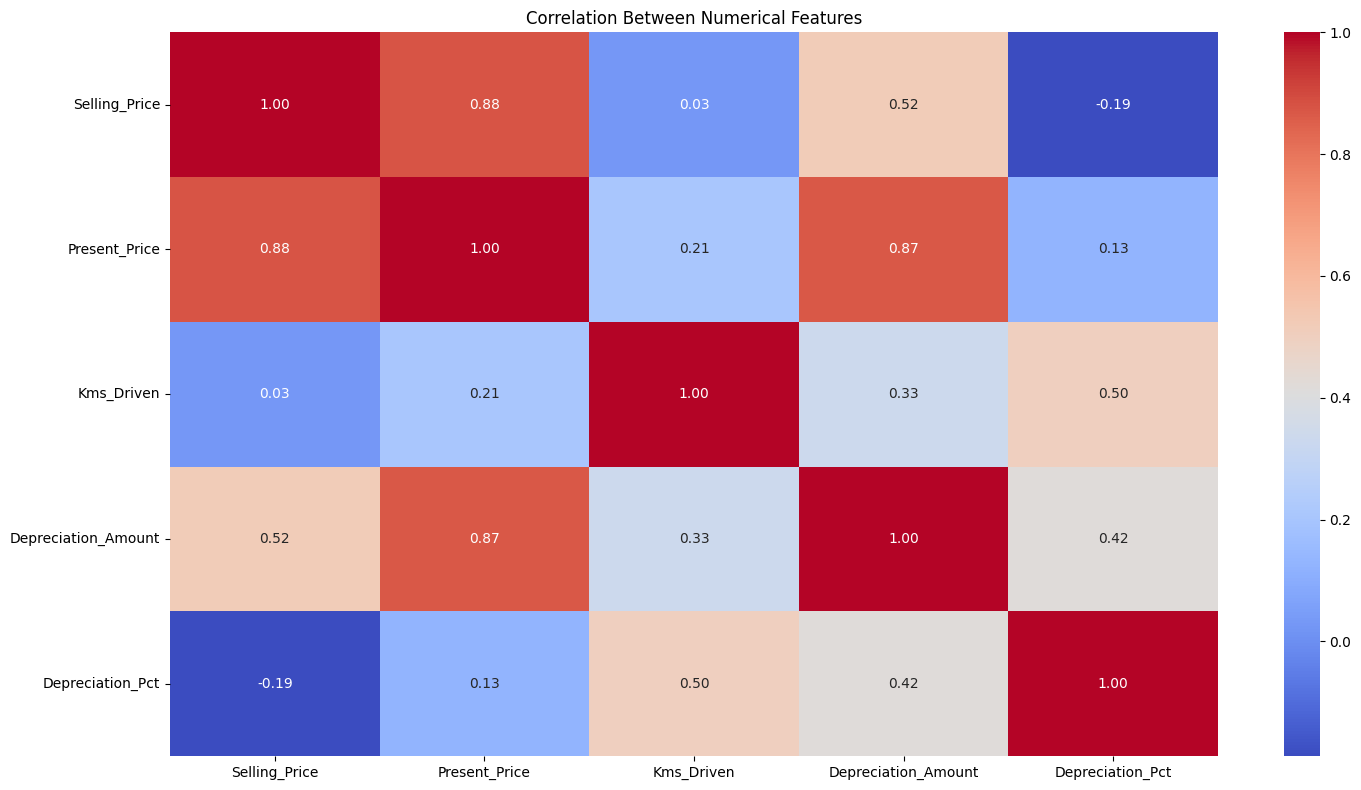

In [22]:
# Correlation Heatmap To check relationship between different columns 
plt.figure(figsize=(15,8))
numerical_cols = ["Selling_Price", "Present_Price", "Kms_Driven", "Depreciation_Amount", "Depreciation_Pct"]
sns.heatmap(df_copy[numerical_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Numerical Features")
plt.savefig("heatmap.jpg")
plt.tight_layout()
plt.show()


# Correlation Between Numerical Features

- Explanation: Original new price (Present_Price) has the strongest positive impact on the used selling price.

- Recommendations:

    - Use original brand value as the primary baseline when pricing a used car.

    - Adjust final valuations downward systematically based on total age and kilometers driven.

# Conclusion 



Automatic cars retain significantly higher market value than manual cars up to 14 years of age. However, once vehicles cross the 15-year mark, the price difference disappears as both types hit low residual values. Dealers and sellers can maximize profit by focusing on automatic cars under 14 years old and clearing out older inventory quickly.